# GEO DATA ANALYSIS FOR THESIS

In [2]:
import pandas as pd
from openpyxl import load_workbook
import numpy as np
import os 
from unidecode import unidecode


## For geocoding
import geopandas as gpd
from shapely.geometry import Point
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from pyproj import Transformer

# For plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [3]:
cd = os.getcwd()
print(cd)
geo = cd+ '/geo'
agro= cd +"/Agromercados"
defens = cd +'/defensoria'


/Users/amh/Desktop/CEU-EDP/THESIS/Data


#### ignore for now, was already done: 

In [16]:

districts = [ "San Rafael Cedros", "Sonzacate", "Concepción de Ataco", "Candelaria de la Frontera",
             "Ilopango", "San Sebastián", "Coatepeque" , "Santiago de María", "Quezaltepeque", "San Julián", "Cuscatancingo"]
# If you already have a dataframe, use:
# districts = raw['district'].drop_duplicates()

markets = pd.DataFrame({'district': districts})
markets['department'] = np.nan  # fill if you have department info

geolocator = Nominatim(user_agent="ceu_thesis_geocoder")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=2, max_retries=1, error_wait_seconds=5, swallow_exceptions=True)

def try_queries(d):
    queries = [
        f"Mercado Municipal de {d}, El Salvador",
        f"Mercado Municipal {d}, El Salvador",
        f"Mecado Central de {d}",
        f"Mercado {d}, El Salvador",
        f"{d}, El Salvador"
    ]
    for q in queries:
        loc = geocode(q, timeout=10)
        if loc:
            return pd.Series({'search_query_used': q, 'lat': loc.latitude, 'lon': loc.longitude})
    return pd.Series({'search_query_used': np.nan, 'lat': np.nan, 'lon': np.nan})

coords = markets['district'].apply(try_queries)
markets = pd.concat([markets, coords], axis=1)

markets.to_csv('municipal_market_coords_40-49.csv', index=False)
markets.head()


,district,department,search_query_used,lat,lon
0,San Rafael Cedros,NaN,"San Rafael Cedros, El Salvador",13.731075,-88.887385
1,Sonzacate,NaN,"Sonzacate, El Salvador",13.754040,-89.707563
2,Concepción de Ataco,NaN,"Mercado Concepción de Ataco, El Salvador",13.868363,-89.850611
3,Candelaria de la Frontera,NaN,Mercado Municipal de Candelaria de la Frontera...,14.115134,-89.650501
4,Ilopango,NaN,"Mercado Municipal de Ilopango, El Salvador",13.691266,-89.130416


In [17]:
## save markets df to geojson
# Drop rows without coordinates first
markets_geo = markets.dropna(subset=['lat', 'lon']).copy()

# Create geometry column
markets_geo['geometry'] = markets_geo.apply(
    lambda row: Point(row['lon'], row['lat']), axis=1
)

# Convert to GeoDataFrame (WGS84 = EPSG:4326)
gdf = gpd.GeoDataFrame(markets_geo, geometry='geometry', crs='EPSG:4326')

# Save to GeoJSON
gdf.to_file('municipal_markets.geojson', driver='GeoJSON')

## District Markets:

### Rural vs. Urban Districts: 

In [4]:
#import excel reader 
districts_urb = cat = pd.read_excel(geo + '/catalogo-de-municipios-y-distritos.xlsx', engine='openpyxl')

# Standardise names a bit
cat['Distrito'] = cat['Distritos'].str.strip()
cat['Municipio'] = cat['Municipios'].str.strip()
cat['Distrito_clean'] = cat['Distrito'].replace({
    "Delgado": "Ciudad Delgado",
    "Santa Tecla antes: Nueva San Salvador": "Santa Tecla",
    "El Rosario / Rosario de La Paz": "El Rosario",
})



In [5]:
#using unidecode

cat['Distrito_key'] = (
    cat['Distrito_clean']
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('ascii')
    .str.lower()
    .str.strip()
)
#mapping names of urban d. 
urban_districts = [
    "Ahuachapán","Santa Ana",
    "Nahuizalco","Izalco","Sonzacate","Sonsonate",
    "San Antonio del Monte","Nahulingo",
    "Ayutuxtepeque","Cuscatancingo","Mejicanos","San Salvador",
    "Ciudad Delgado","Ilopango","San Martín","Soyapango",
    "Tonacatepeque","Apopa","Nejapa","Panchimalco",
    "San Marcos","Santiago Texacuangos","Santo Tomás",
    "San Juan Opico","Antiguo Cuscatlán","Colón","Santa Tecla",
    "San Miguel",
]

urban_districts_raw = urban_districts


#### source for rural vs. urban mapping: 
https://diario.elmundo.sv/economia/estos-son-los-6-centros-urbanos-y-sus-28-ciudades-de-el-salvador

According to EU DEGUBA: these are the 28 cities

In [6]:
urban_keys = [unidecode(x).lower().strip() for x in urban_districts_raw]

cat['is_urban_deg'] = cat['Distrito_key'].isin(urban_keys).astype(int)

missing = set(urban_keys) - set(cat.loc[cat['is_urban_deg'] == 1, 'Distrito_key'])
print("Still missing:", missing)

urban_keys = [unidecode(x).lower().strip() for x in urban_districts_raw]
cat

Still missing: set()


,Distritos,Municipios,Distrito,Municipio,Distrito_clean,Distrito_key,is_urban_deg
0,Ahuachapán,Ahuachapán Centro,Ahuachapán,Ahuachapán Centro,Ahuachapán,ahuachapan,1
1,Apaneca,Ahuachapán Centro,Apaneca,Ahuachapán Centro,Apaneca,apaneca,0
2,Concepción de Ataco,Ahuachapán Centro,Concepción de Ataco,Ahuachapán Centro,Concepción de Ataco,concepcion de ataco,0
3,Tacuba,Ahuachapán Centro,Tacuba,Ahuachapán Centro,Tacuba,tacuba,0
4,Atiquizaya,Ahuachapán Norte,Atiquizaya,Ahuachapán Norte,Atiquizaya,atiquizaya,0
...,...,...,...,...,...,...,...
257,La Unión,La Unión Sur,La Unión,La Unión Sur,La Unión,la union,0
258,Meanguera del Golfo,La Unión Sur,Meanguera del Golfo,La Unión Sur,Meanguera del Golfo,meanguera del golfo,0
259,San Alejo,La Unión Sur,San Alejo,La Unión Sur,San Alejo,san alejo,0
260,Yayantique,La Unión Sur,Yayantique,La Unión Sur,Yayantique,yayantique,0


In [7]:
cols_drop = ['Distritos', 'Municipios', 'Distrito']
cat= cat.drop(columns=cols_drop)

In [8]:
#arbritrary distance: if is_urban_deg = 1 then dist: 3.5km, else 7km
cat['arb_dis_km'] = np.where(cat['is_urban_deg'] == 1, 3.5, 7)
cat.head()
cat.to_csv("mun_and_distrito_with_urban_and_arb_dist.csv", index=False)
cat.head()

,Municipio,Distrito_clean,Distrito_key,is_urban_deg,arb_dis_km
0,Ahuachapán Centro,Ahuachapán,ahuachapan,1,3.5
1,Ahuachapán Centro,Apaneca,apaneca,0,7.0
2,Ahuachapán Centro,Concepción de Ataco,concepcion de ataco,0,7.0
3,Ahuachapán Centro,Tacuba,tacuba,0,7.0
4,Ahuachapán Norte,Atiquizaya,atiquizaya,0,7.0


--------------------------------------------

## Agromercados:

In [9]:
#load agromercado data: 
df_agro = pd.read_csv(agro + '/agromercados_coordinates_apertura.csv')
print(df_agro)

               Agromercado          Municipio    Latitud   Longitud  \
0               Ahuachapán  Ahuachapán Centro  13.919177 -89.846879   
1               Atiquizaya   Ahuachapán Norte  13.972247 -89.758196   
2   San Francisco Menéndez     Ahuachapán Sur  13.784973 -90.035534   
3            Sensuntepeque       Cabañas Este  13.874880 -88.630029   
4                 Ilobasco      Cabañas Oeste  13.841282 -88.847347   
..                     ...                ...        ...        ...   
56                Usulután    Usulután Centro  13.352125 -88.438139   
57                  Berlín     Usulután Norte  13.499011 -88.532858   
58              El Triunfo     Usulután Norte  13.563224 -88.425430   
59       Santiago de María     Usulután Norte  13.481133 -88.469392   
60              Jiquilisco     Usulután Oeste  13.325156 -88.565147   

      Apertura  
0   13/08/2024  
1   21/05/2025  
2   10/07/2024  
3   11/07/2024  
4   01/08/2024  
..         ...  
56  13/08/2024  
57  08/11/2

In [10]:
df_agro["Agromercado"].unique()

array(['Ahuachapán', 'Atiquizaya', 'San Francisco Menéndez',
       'Sensuntepeque', 'Ilobasco', 'El Paraíso', 'Nueva Concepción',
       'Chalatenango', 'San Rafael Cedros', 'Cojutepeque', 'Suchitoto',
       'Ciudad Arce', 'San Juan Opico', 'La Libertad (Puerto)',
       'Zaragoza', 'Quezaltepeque', 'Colón', 'Santa Tecla',
       'Santa Tecla Cafetalón', 'Zacatecoluca', 'Olocuilta', 'La Unión',
       'Santa Rosa de Lima', 'Anamorós', 'Meanguera',
       'San Francisco Gotera', 'Corinto', 'Jocoro', 'Chinameca',
       'El Tránsito', 'Calle Chaparrastique', 'Estadio Barraza',
       'Ciudad Barrios', 'Ayutuxtepeque', 'Ciudad Delgado', 'Mejicanos',
       'Ilopango', 'Ilopango Alta Vista', 'San Martín', 'Soyapango',
       'Aguilares', 'Apopa', 'San Marcos', 'Santo Tomás', 'Apastepeque',
       'San Vicente', 'Santa Ana (El Palmar)', 'Santa Ana (IVU)',
       'El Congo', 'Metapán', 'Chalchuapa', 'Sonsonate', 'Armenia',
       'Izalco', 'Juayúa', 'Acajutla', 'Usulután', 'Berlín', 'El Tr

In [11]:
# ------------------------------------------------------------------
# Cast to float and validate against El Salvador bbox
# ------------------------------------------------------------------
df_agro['Latitud']  = pd.to_numeric(df_agro['Latitud'],  errors='coerce')
df_agro['Longitud'] = pd.to_numeric(df_agro['Longitud'], errors='coerce')

bbox_mask = (
    df_agro['Latitud'].between(13.1, 14.5) &
    df_agro['Longitud'].between(-90.2, -87.6)
)
invalid = df_agro[~bbox_mask]
if len(invalid) > 0:
    print(f"\nWARNING: {len(invalid)} row(s) still outside El Salvador bbox after fixes:")
    print(invalid[['Agromercado', 'Municipio', 'Latitud', 'Longitud']])


--------

## Baseline map

In [12]:

# --------------------------
# 1) Bounding box El Salvador → Web Mercator
# --------------------------
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
xmin, ymin = transformer.transform(-90.2, 13.1)
xmax, ymax = transformer.transform(-87.6, 14.5)

# --------------------------
# 2) Load municipal markets
# --------------------------
gdf = gpd.read_file('/Users/amh/Desktop/CEU-EDP/THESIS/Data/geo/municipal_market_coords.geojson').dropna(subset=['lat', 'lon'])
gdf_web = gdf.to_crs(epsg=3857)

# --------------------------
# 3) Load Agromercados
# --------------------------
agros = pd.read_csv(agro + '/agromercados_coordinates_apertura.csv')
agro_gdf = gpd.GeoDataFrame(
    agros,
    geometry=gpd.points_from_xy(agros['Longitud'], agros['Latitud']),
    crs='EPSG:4326'
)
agro_web = agro_gdf.to_crs(epsg=3857)



# --------------------------
# 4) Flag misplaced geocoded points and print name of market
# --------------------------
bad = gdf[
    (gdf['lat'] < 13.1) | (gdf['lat'] > 14.5) |
    (gdf['lon'] < -90.2) | (gdf['lon'] > -87.6)
]
if len(bad) > 0:
    print(f"WARNING: {len(bad)} points outside El Salvador bbox:")
    print(bad[['district', 'lat', 'lon', 'search_query_used']])

# Remove bad points from plot
mask = (
    (gdf['lat'] >= 13.1) & (gdf['lat'] <= 14.5) &
    (gdf['lon'] >= -90.2) & (gdf['lon'] <= -87.6)
)
gdf_web = gdf_web[mask]

# --------------------------
# 5) Agromercado 5km buffer
# --------------------------
agro_utm = agro_web.to_crs(epsg=32616).copy()       # UTM zone 16N, metres
agro_utm['geometry'] = agro_utm.geometry.buffer(5_000)
agro_buffer = agro_utm.to_crs(epsg=3857)


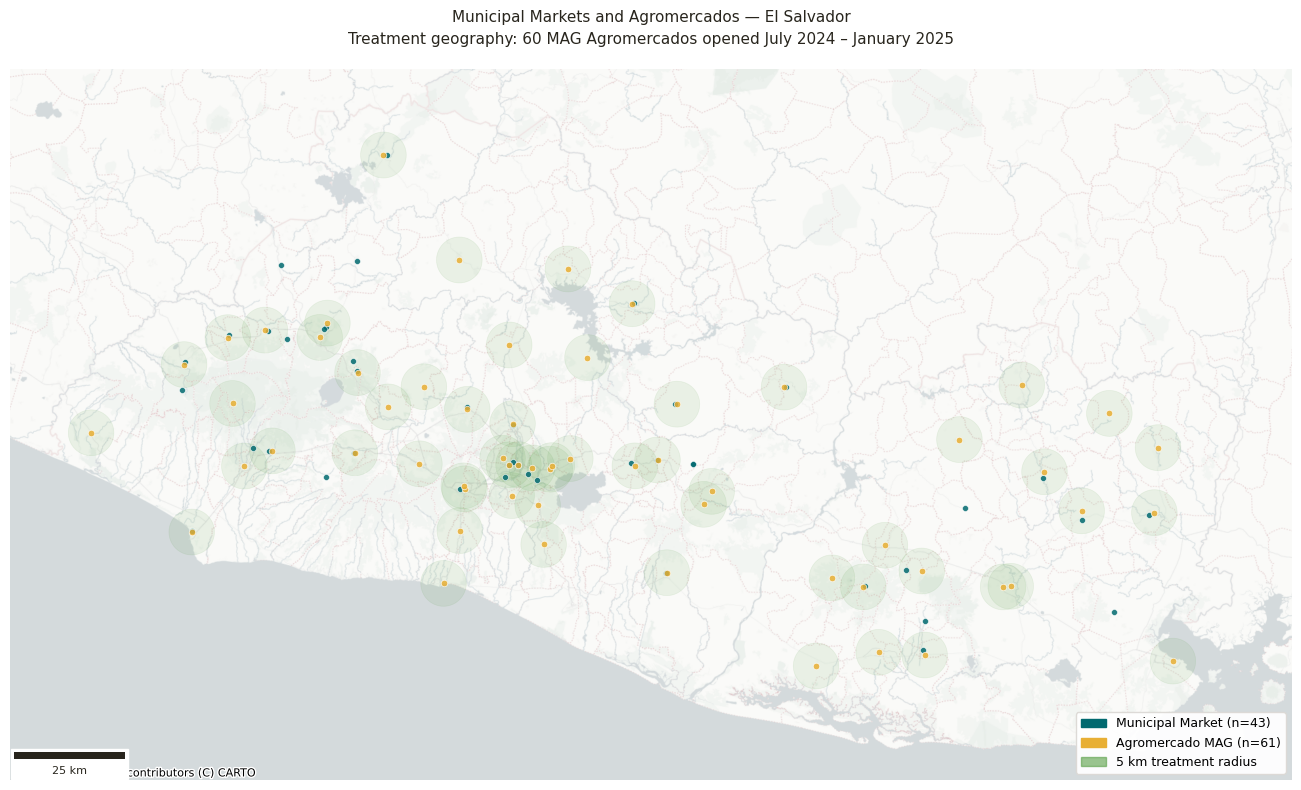

In [13]:

# --------------------------
# 6) Plot
# --------------------------
f, ax = plt.subplots(1, 1, figsize=(16, 8))

# Set bbox BEFORE basemap
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Minimal basemap
ctx.add_basemap(
    ax,
    crs='EPSG:3857',
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=10
)

# Agromercado buffers (background)
agro_buffer.plot(
    ax=ax, color="#589f45b9", alpha=0.10,
    edgecolor='#589f45b9', linewidth=0.5, zorder=3
)

# Municipal market points
gdf_web.plot(
    ax=ax, color='#01696f', markersize=18,
    alpha=0.85, edgecolor='white', linewidth=0.4, zorder=5
)

# Agromercado points
agro_web.plot(
    ax=ax, color='#e8af34', markersize=22, 
    #make transparent 
    alpha=0.85, edgecolor='white', linewidth=0.5, zorder=6
)

# --------------------------
# 7) Legend
# --------------------------
legend_elements = [
    mpatches.Patch(color='#01696f', label=f'Municipal Market (n={len(gdf_web)})'),
    mpatches.Patch(color='#e8af34', label=f'Agromercado MAG (n={len(agro_web)})'),
    mpatches.Patch(color="#589f45b9", alpha=0.6, label='5 km treatment radius'),
]
ax.legend(
    handles=legend_elements, fontsize=9, loc='lower right',
    frameon=True, framealpha=0.95, edgecolor='#dcd9d5'
)

# --------------------------
# 8) Title
# --------------------------
ax.set_title(
    'Municipal Markets and Agromercados — El Salvador\n'
    'Treatment geography: 60 MAG Agromercados opened July 2024 – January 2025',
    fontsize=11, pad=18, color='#28251d', linespacing=1.6
)

ax.axis('off')
f.patch.set_facecolor('white')

# --------------------------
# 9) Scale bar (optional)
# --------------------------
try:
    from matplotlib_scalebar.scalebar import ScaleBar
    ax.add_artist(ScaleBar(1, location='lower left',
                           length_fraction=0.15,
                           font_properties={'size': 8},
                           color='#28251d'))
except ImportError:
    print("pip install matplotlib-scalebar  ← to add scale bar")

plt.tight_layout()
plt.savefig('figures/markets_vs_agromercados_final_5km.png', dpi=600, facecolor='white')
plt.show()

------------

## 4. Calculate distance by best route using Open Source Routing Maching (OSRM)
This will be used to define treatment and control groups clustering

In [14]:
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
import time


In [15]:
# OSRM public demo server
# driving = fastest road route
# --------------------------
OSRM_BASE = "http://router.project-osrm.org/route/v1/driving"
HEADERS   = {"User-Agent": "agromercado-thesis-CEU/1.0"}

In [17]:
def osrm_route(origin_lon, origin_lat, dest_lon, dest_lat):
    """
    Query OSRM for the fastest driving route between two points.
    Returns dict with distance_km, duration_min, and geometry (LineString).
    Returns None on failure.
    """
    url = (
        f"{OSRM_BASE}/"
        f"{origin_lon},{origin_lat};"
        f"{dest_lon},{dest_lat}"
        f"?overview=full&geometries=geojson&steps=false"
    )
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok":
            return None
        leg = data["routes"][0]
        coords = leg["geometry"]["coordinates"]   # [[lon,lat], ...]
        return {
            "distance_km":   round(leg["distance"] / 1000, 5),
            "duration_min":  round(leg["duration"] / 60, 2),
            "route_geometry": LineString(coords)
        }
    except Exception as e:
        print(f"  [OSRM ERR] ({origin_lon:.4f},{origin_lat:.4f}) → ({dest_lon:.4f},{dest_lat:.4f}): {e}")
        return None


# --------------------------
# Load datasets
# (assumes gdf and agro_gdf already in memory from your mapping script;
#  if not, reload them below)
# --------------------------
gdf      = gpd.read_file(geo + '/municipal_market_coords.geojson').dropna(subset=['lat','lon'])
agro_gdf = gpd.GeoDataFrame(agros, geometry=gpd.points_from_xy(agros['Longitud'], agros['Latitud']), crs='EPSG:4326')

# Work in EPSG:4326 for OSRM (it expects WGS84 lon/lat)
markets = gdf[['district', 'lat', 'lon']].copy().reset_index(drop=True)
agros_coords = agro_gdf[['Agromercado', 'Municipio', 'Latitud', 'Longitud']].copy().reset_index(drop=True)


# --------------------------
# Step 1: Find closest agromercado (Euclidean) as candidate
#         → avoids querying OSRM for every pair (O(n×m) calls)
# --------------------------
from scipy.spatial import cKDTree

agro_xy = agros_coords[['Longitud', 'Latitud']].values
tree    = cKDTree(agro_xy)

# Query 3 nearest candidates per market (in case closest by air is far by road)
N_CANDIDATES = 3
dists, idxs = tree.query(markets[['lon', 'lat']].values, k=N_CANDIDATES)

print(f"Markets: {len(markets)} | Agromercados: {len(agros_coords)}")
print(f"Querying OSRM for up to {N_CANDIDATES} candidates per market...\n")


# --------------------------
# Step 2: OSRM route for each candidate → keep shortest road distance
# --------------------------
results = []

for i, market_row in markets.iterrows():
    mkt_lon, mkt_lat = market_row['lon'], market_row['lat']
    mkt_name         = market_row['district']

    best = None

    for j, cand_idx in enumerate(idxs[i]):
        agro_row = agros_coords.iloc[cand_idx]
        agro_lon = agro_row['Longitud']
        agro_lat = agro_row['Latitud']

        route = osrm_route(mkt_lon, mkt_lat, agro_lon, agro_lat)
        time.sleep(0.5)   # respect OSRM demo server rate limit

        if route is None:
            continue

        if best is None or route['distance_km'] < best['distance_km']:
            best = {
                "market_district":   mkt_name,
                "market_lat":        mkt_lat,
                "market_lon":        mkt_lon,
                "closest_agro":      agro_row['Agromercado'],
                "agro_municipio":    agro_row['Municipio'],
                "agro_lat":          agro_lat,
                "agro_lon":          agro_lon,
                "distance_km":       route['distance_km'],
                "duration_min":      route['duration_min'],
                "route_geometry":    route['route_geometry'],
                "euclidean_rank":    j + 1   # which candidate won
            }

    if best:
        results.append(best)
        print(f"  [{i+1:03d}] {mkt_name:30s} → {best['closest_agro']:30s} "
              f"| {best['distance_km']:6.2f} km | {best['duration_min']:5.1f} min")
    else:
        print(f"  [{i+1:03d}] {mkt_name:30s} → OSRM FAILED all candidates")


# --------------------------
# Step 3: Build results DataFrame + GeoDataFrame of routes
# --------------------------
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'route_geometry'}
                            for r in results])

routes_gdf = gpd.GeoDataFrame(
    results_df,
    geometry=[r['route_geometry'] for r in results],
    crs='EPSG:4326'
)

print(f"\n--- Summary ---")
print(f"Routes computed : {len(results_df)}")
print(f"Mean road dist  : {results_df['distance_km'].mean():.2f} km")
print(f"Median road dist: {results_df['distance_km'].median():.2f} km")
print(f"Max road dist   : {results_df['distance_km'].max():.2f} km")
print(results_df[['market_district','closest_agro','distance_km','duration_min']].to_string(index=False))


Markets: 43 | Agromercados: 61
Querying OSRM for up to 3 candidates per market...

  [001] Cojutepeque                    → Cojutepeque                    |   1.25 km |   2.6 min
  [002] Ahuachapán                     → Ahuachapán                     |   0.86 km |   1.7 min
  [003] El Congo                       → El Congo                       |   0.33 km |   0.8 min
  [004] La Unión                       → La Unión                       |  22.90 km |  22.7 min
  [005] Atiquizaya                     → Atiquizaya                     |   0.64 km |   0.9 min
  [006] Chalchuapa                     → Chalchuapa                     |   1.51 km |   2.1 min
  [007] Metapán                        → Metapán                        |   1.19 km |   2.9 min
  [008] El Tránsito                    → El Tránsito                    |   1.55 km |   3.2 min
  [009] San Francisco Gotera           → San Francisco Gotera           |   1.63 km |   3.5 min
  [010] Apopa                          → Apopa       

In [18]:
# --------------------------
# Step 4: Export
# --------------------------
results_df.to_csv(geo + "/market_to_agro_routes_5KM.csv", index=False)
routes_gdf.to_file(geo + "/market_to_agro_routes_5KM.geojson", driver="GeoJSON")
print("\nSaved: " + geo + "/market_to_agro_routes_5KM.csv")
print("Saved: " + geo + "/market_to_agro_routes_5KM.geojson")


Saved: /Users/amh/Desktop/CEU-EDP/THESIS/Data/geo/market_to_agro_routes_5KM.csv
Saved: /Users/amh/Desktop/CEU-EDP/THESIS/Data/geo/market_to_agro_routes_5KM.geojson


In [19]:
# ── SECTION 5: TREATMENT ASSIGNMENT ──────────────────────────────────

import pandas as pd
from unidecode import unidecode

# 5.1 Load OSRM results + apertura dates
routes   = pd.read_csv(geo + '/market_to_agro_routes_5KM.csv')
apertura = pd.read_csv(agro + '/agromercados_coordinates_apertura.csv')


In [20]:
routes.head()

,market_district,market_lat,market_lon,closest_agro,agro_municipio,agro_lat,agro_lon,distance_km,duration_min,euclidean_rank
0,Cojutepeque,13.724652,-88.940868,Cojutepeque,Cuscatlán Sur,13.719779,-88.932731,1.2458,2.64,1
1,Ahuachapán,13.924976,-89.845833,Ahuachapán,Ahuachapán Centro,13.919177,-89.846879,0.8582,1.73,1
2,El Congo,13.905658,-89.496721,El Congo,Santa Ana Este,13.903452,-89.495145,0.3251,0.79,1
3,La Unión,13.430718,-87.961151,La Unión,La Unión Norte,13.334752,-87.841385,22.9033,22.72,1
4,Atiquizaya,13.976651,-89.755530,Atiquizaya,Ahuachapán Norte,13.972247,-89.758196,0.6412,0.86,1


In [21]:
apertura['apertura_date'] = pd.to_datetime(apertura['Apertura'], dayfirst=True)
apertura['first_treated_week'] = apertura['apertura_date'].dt.strftime('%G-W%V')
apertura.drop(columns=['Apertura'], inplace=True)
print(apertura.head())

              Agromercado          Municipio    Latitud   Longitud  \
0              Ahuachapán  Ahuachapán Centro  13.919177 -89.846879   
1              Atiquizaya   Ahuachapán Norte  13.972247 -89.758196   
2  San Francisco Menéndez     Ahuachapán Sur  13.784973 -90.035534   
3           Sensuntepeque       Cabañas Este  13.874880 -88.630029   
4                Ilobasco      Cabañas Oeste  13.841282 -88.847347   

  apertura_date first_treated_week  
0    2024-08-13           2024-W33  
1    2025-05-21           2025-W21  
2    2024-07-10           2024-W28  
3    2024-07-11           2024-W28  
4    2024-08-01           2024-W31  


In [22]:
# 5.2 — Build clean merge keys
norm = lambda x: unidecode(str(x)).lower().strip()

apertura['agro_key'] = apertura['Agromercado'].apply(norm)
routes['agro_key']   = routes['closest_agro'].apply(norm)

# 5.3 — Merge ONLY apertura_date; first_treated_week computed fresh below
routes = routes.merge(
    apertura[['agro_key', 'apertura_date']],
    on='agro_key',
    how='left'
)

# 5.4 — Diagnose unmatched BEFORE proceeding
unmatched = routes[routes['apertura_date'].isna()]
if len(unmatched):
    print("⚠️  Unmatched closest_agro values:")
    print(unmatched[['market_district', 'closest_agro', 'agro_key']].to_string(index=False))
    print("\nAvailable apertura keys:")
    print(sorted(apertura['agro_key'].tolist()))
else:
    print("✅ All 43 markets matched to an apertura date")


# 5.5 — Treatment thresholds
routes['apertura_date']      = pd.to_datetime(routes['apertura_date'])
routes['first_treated_week'] = routes['apertura_date'].dt.strftime('%G-W%V')

# This loop creates the 3km, 5km, and 10km assignment columns
for km in [3, 5, 10]:
    routes[f'treated_{km}km'] = (routes['distance_km'] <= km).astype(int)

# Never-treated sentinel — overwrite first_treated_week only for never-treated
# To change the primary treatment distance, change 'treated_3km' to 'treated_5km' or 'treated_10km'
never_mask = routes['treated_5km'] == 0      
routes.loc[never_mask, 'first_treated_week'] = '0'


✅ All 43 markets matched to an apertura date


In [23]:
# 5.6 — Summary
print("\n── Treatment counts by threshold ──")
for km in [3, 5, 10]:
    t = routes[f'treated_{km}km'].sum()
    c = (routes[f'treated_{km}km'] == 0).sum()
    print(f"  {km:>2} km : treated={t:>2}  never-treated={c:>2}")

# UPDATE HERE: Change text and filter to 5km
print("\n── Never-treated markets at 5 km ──")
print(routes[routes['treated_5km'] == 0][
    ['market_district', 'closest_agro', 'distance_km', 'apertura_date']
].to_string(index=False))

# UPDATE HERE: Change filter to 5km
print("\n── Treated cohorts (first_treated_week) ──")
print(routes[routes['treated_5km'] == 1][
    ['market_district', 'closest_agro', 'distance_km', 'first_treated_week']
].sort_values('first_treated_week').to_string(index=False))


── Treatment counts by threshold ──
   3 km : treated=28  never-treated=15
   5 km : treated=32  never-treated=11
  10 km : treated=36  never-treated= 7

── Never-treated markets at 5 km ──
          market_district      closest_agro  distance_km apertura_date
                 La Unión          La Unión      22.9033    2024-08-13
             Texistepeque   Santa Ana (IVU)      18.2729    2024-07-10
              Chapeltique    Ciudad Barrios      17.0454    2024-09-19
 San Sebastián Salitrillo        Chalchuapa       7.4173    2024-08-22
              San Vicente San Rafael Cedros      10.4233    2024-09-19
               San Miguel       El Tránsito       8.7085    2024-11-08
      Concepción de Ataco        Ahuachapán       8.8463    2024-08-13
Candelaria de la Frontera        Chalchuapa      20.1956    2024-08-22
                 Ilopango          Ilopango       5.0923    2024-08-01
            San Sebastián San Rafael Cedros      10.4233    2024-09-19
               San Julián   

In [27]:

# 5.7 — Export
cols_export = [
    'market_district', 'market_lat', 'market_lon',
    'closest_agro', 'agro_municipio', 'agro_lat', 'agro_lon',
    'distance_km', 'duration_min', 'euclidean_rank',
    'apertura_date', 'first_treated_week',
    'treated_3km', 'treated_5km', 'treated_10km'
]
routes[cols_export].to_csv(geo + '/treatment_assignment_5KM.csv', index=False)
print("\n✅ Saved: treatment_assignment_5KM.csv")


✅ Saved: treatment_assignment_5KM.csv


## map for treatment and control:

In [25]:
### red for urban, green for rural districts
# --------------------------
# 4) Flag misplaced geocoded points
# --------------------------
bad = gdf[
    (gdf['lat'] < 13.1) | (gdf['lat'] > 14.5) |
    (gdf['lon'] < -90.2) | (gdf['lon'] > -87.6)
]
if len(bad) > 0:
    print(f"WARNING: {len(bad)} points outside El Salvador bbox:")
    print(bad[['district', 'lat', 'lon', 'search_query_used']])

# Remove bad points from plot
mask = (
    (gdf['lat'] >= 13.1) & (gdf['lat'] <= 14.5) &
    (gdf['lon'] >= -90.2) & (gdf['lon'] <= -87.6)
)
gdf_web = gdf_web[mask]


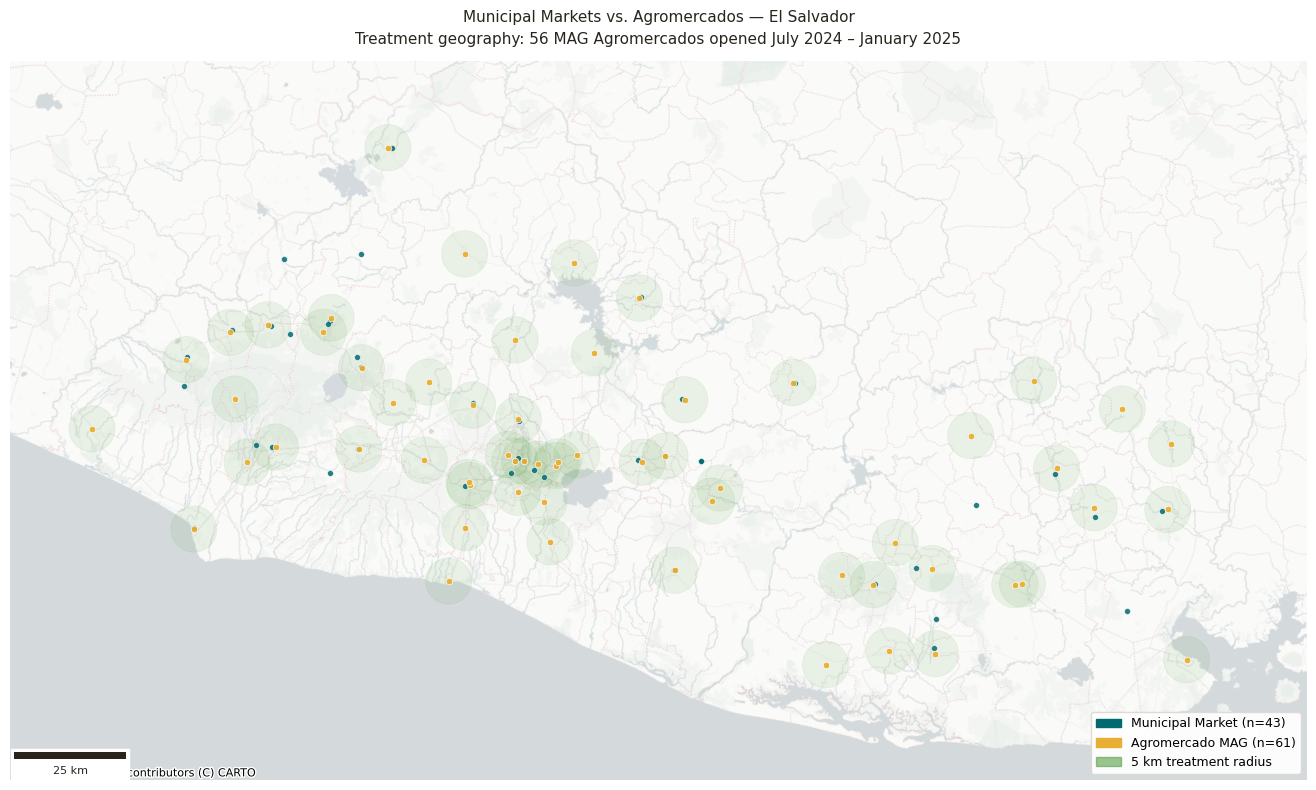

In [26]:

# --------------------------
# 5) Agromercado 10km buffer
# --------------------------
agro_utm = agro_web.to_crs(epsg=32616).copy()       # UTM zone 16N, metres
agro_utm['geometry'] = agro_utm.geometry.buffer(5_000)
agro_buffer = agro_utm.to_crs(epsg=3857)

# --------------------------
# 6) Plot
# --------------------------
f, ax = plt.subplots(1, 1, figsize=(16, 8))

# Set bbox BEFORE basemap
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Minimal basemap
ctx.add_basemap(
    ax,
    crs='EPSG:3857',
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=10
)

# Agromercado buffers (background)
agro_buffer.plot(
    ax=ax, color="#589f45b9", alpha=0.10,
    edgecolor='#589f45b9', linewidth=0.5, zorder=3
)

# Municipal market points
gdf_web.plot(
    ax=ax, color='#01696f', markersize=18,
    alpha=0.85, edgecolor='white', linewidth=0.4, zorder=5
)

# Agromercado points
agro_web.plot(
    ax=ax, color='#e8af34', markersize=22,
    alpha=0.95, edgecolor='white', linewidth=0.5, zorder=6
)

# --------------------------
# 7) Legend
# --------------------------
legend_elements = [
    mpatches.Patch(color='#01696f', label=f'Municipal Market (n={len(gdf_web)})'),
    mpatches.Patch(color='#e8af34', label=f'Agromercado MAG (n={len(agro_web)})'),
    mpatches.Patch(color="#589f45b9", alpha=0.6, label='5 km treatment radius'),
]
ax.legend(
    handles=legend_elements, fontsize=9, loc='lower right',
    frameon=True, framealpha=0.95, edgecolor='#dcd9d5'
)

# --------------------------
# 8) Title
# --------------------------
ax.set_title(
    'Municipal Markets vs. Agromercados — El Salvador\n'
    'Treatment geography: 56 MAG Agromercados opened July 2024 – January 2025',
    fontsize=11, pad=12, color='#28251d', linespacing=1.6
)

ax.axis('off')
f.patch.set_facecolor('white')

# --------------------------
# 9) Scale bar (optional)
# --------------------------
try:
    from matplotlib_scalebar.scalebar import ScaleBar
    ax.add_artist(ScaleBar(1, location='lower left',
                           length_fraction=0.15,
                           font_properties={'size': 8},
                           color='#28251d'))
except ImportError:
    print("pip install matplotlib-scalebar  ← to add scale bar")

plt.tight_layout()
plt.savefig('figures/markets_vs_agromercados_final_5km.png', dpi=600, facecolor='white')
plt.show()